In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from matplotlib_venn import venn2
import seaborn as sns
from scipy import stats
import re

plt.rcParams['svg.fonttype'] = 'none'

In [2]:
dfELM = pd.read_csv('../Data/ELM_mutations.csv')
dfACT = pd.read_csv('../Data/DMSactivities.csv')
dfRE = pd.read_csv('../Data/RePred_Activity_merged.csv')
clinvar = pd.read_csv('../Data/clinvar_missense.csv', index_col=0)

clinvar = clinvar.rename(columns={'Protein change': 'mutation'})

df = dfELM.merge(dfACT, on='mutation', how='left')
df = df.merge(dfRE[['mutation', 'mut_vs_wt_Re_logFC_50', 'mut_vs_wt_Re_delta_50']], on='mutation', how='left')

df['in_clinvar'] = df['mutation'].isin(clinvar['mutation'])


In [3]:
df = df[df['var_pos'] >= 100].dropna()

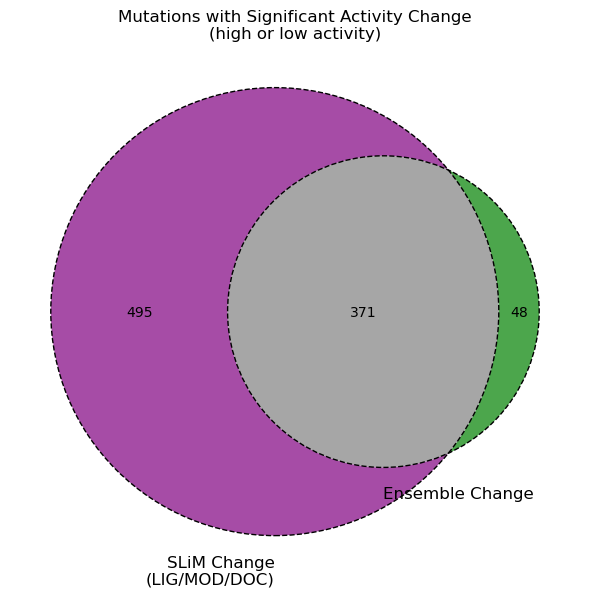

In [6]:
# Restrict to significant activity changes only
df_sig = df[df['classification'].isin(['high_activity', 'low_activity'])].copy()

# SLiM change: any LIG, MOD, or DOC added or removed
df_sig['has_slim_change'] = (
    (df_sig['LIG_added']  > 0) | (df_sig['LIG_removed']  > 0) |
    (df_sig['MOD_added']  > 0) | (df_sig['MOD_removed']  > 0) |
    (df_sig['DOC_added']  > 0) | (df_sig['DOC_removed']  > 0)
)

# Ensemble change: |mut_vs_wt_Re_delta_50| > 0.5
df_sig['has_ensemble_change'] = df_sig['mut_vs_wt_Re_delta_50'].abs() > 0.5

set_slim     = set(df_sig.index[df_sig['has_slim_change']])
set_ensemble = set(df_sig.index[df_sig['has_ensemble_change']])

from matplotlib_venn import venn2, venn2_circles

fig, ax = plt.subplots(figsize=(6, 6))
v = venn2(
    [set_slim, set_ensemble],
    set_labels=('SLiM Change\n(LIG/MOD/DOC)', 'Ensemble Change'),
    ax=ax
)

v.get_patch_by_id('10').set(facecolor='purple', alpha=0.7)
v.get_patch_by_id('01').set(facecolor='green',  alpha=0.7)
v.get_patch_by_id('11').set(facecolor='grey',   alpha=0.7)

c = venn2_circles([set_slim, set_ensemble], ax=ax)
for circle in c:
    circle.set(edgecolor='black', linestyle='dashed', linewidth=1, fill=False)

ax.set_title('Mutations with Significant Activity Change\n(high or low activity)', fontsize=12)
plt.tight_layout()
plt.show()